# 《LangChain RAG文本处理实验》

## 一、实验目的
1. 理解 RAG（检索增强生成）的核心概念与实现流程
2. 理解 LangChain 在 RAG 中的核心组件与作用
3. 掌握文档加载器的使用方法，包括内置加载器和自定义加载器
4. 掌握递归文本分割器（RecursiveCharacterTextSplitter）的用法
5. 掌握按标题分割Markdown文件的方法

## 二、实验环境
- 系统：Windows 10
- Python版本：3.10
- 虚拟环境：Miniconda
- 开发工具：VS Code / Jupyter Notebook
- 依赖库：langchain、langchain-core、langchain-community、langchain-text-splitters、langchain-unstructured、python-dotenv
- 模型：DeepSeek（deepseek-chat）


## 三、实验原理

### 3.1 LangChain组件

LangChain 框架提供了丰富的组件帮助我们搭建 RAG 应用，下面是关于这些核心组件的介绍：

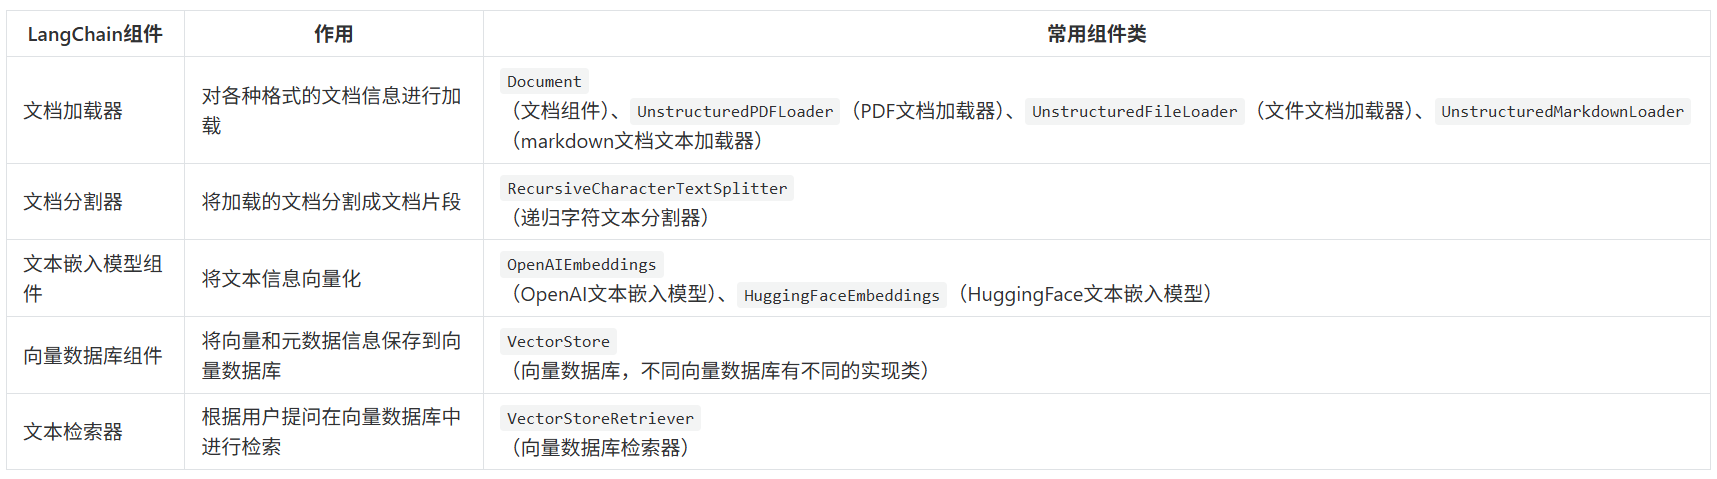

### 3.2 LangChain实现流程

在RAG准备阶段，LangChain通过文档加载器对各种格式的文档进行加载，转换为LangChain中的文档对象，之后对文档对象进行分割，根据分割规则，分割成文档片段。

![下载 (4).jpg](<attachment:下载 (4).jpg>)

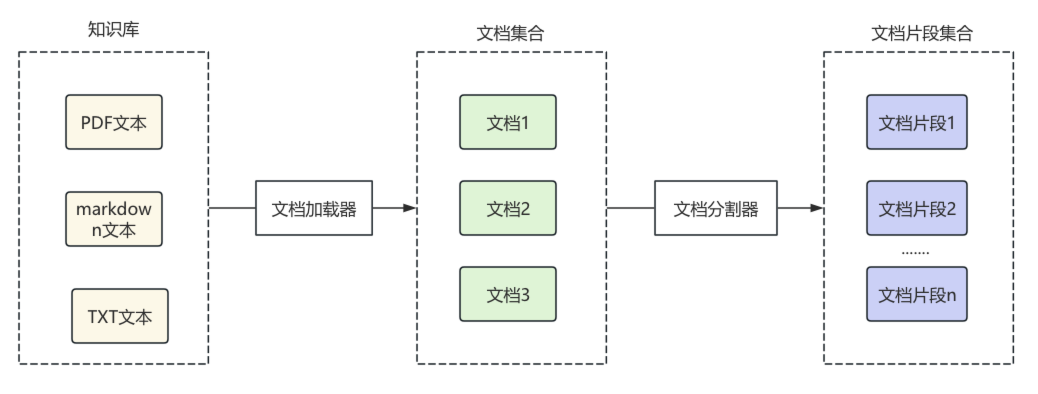

之后，将文档片段通过文本嵌入模型组件，转换为向量，通过向量数据库组件，保存到向量数据库，每个向量通常还会绑定原文内容、文档ID、来源等元数据信息，便于后面数据检索。

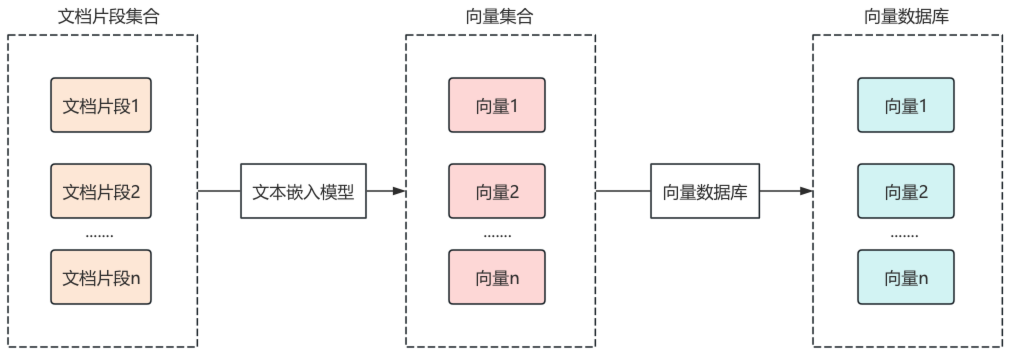

在RAG的使用阶段，用户首先提出问题，使用文本嵌入模型组件，将提问文本转换为向量数据，通过向量数据库检索器组件，进行相似性检索，返回关联的文本片段。

将相关的文档片段内容渲染到提示词模板中，作为提问问题的上下文传递给大语言模型，大语言模型输出结果，再传递给输出解析器，最终结果通过输出解析器处理后返回给用户，这样就完成了一次RAG检索。

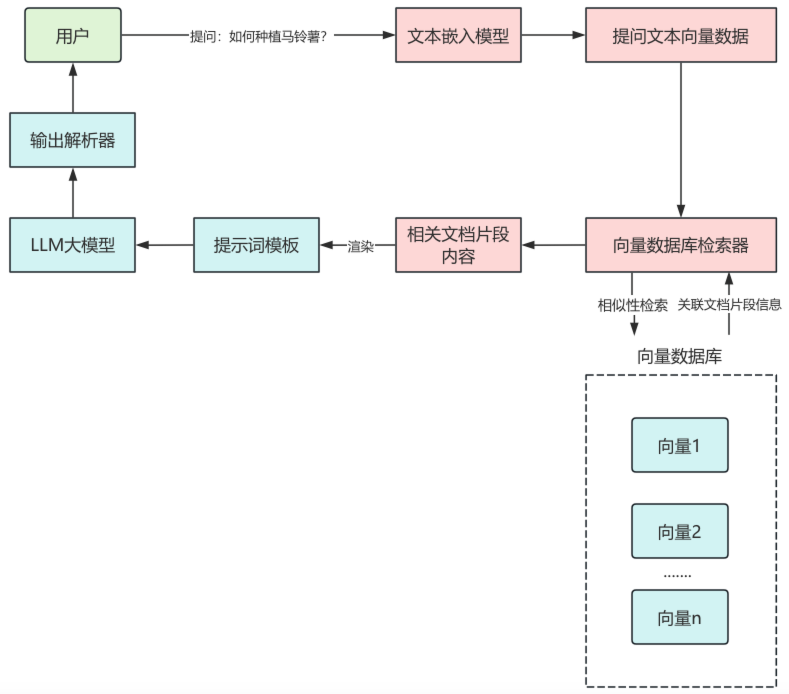

### 3.3 文档加载器

在LangChain中，文档加载器用于将各种格式的文档转换为Document对象，LangChain提供了大量的文档加载器，支持从各种来源加载文档，如文件、数据源、URL等。

常用的LangChain文档加载器如下：

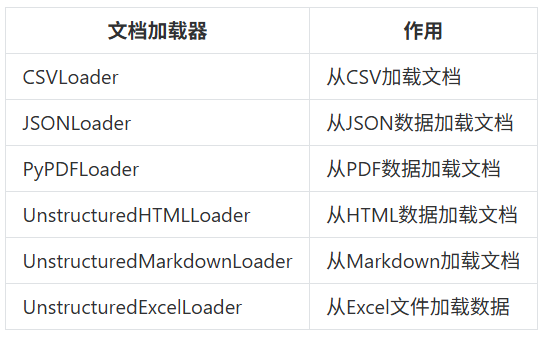

### 3.4 文本分割器

LangChain提供了多种文本分割器，常用的有：

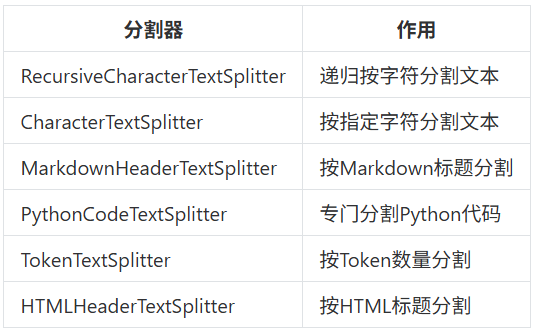

## 四、实验内容

### 4.1 环境准备

安装依赖库。

In [ ]:
%pip install unstructured
%pip install markdown

### 4.2 文档加载器使用

以UnstructuredMarkdownLoader为例来介绍文档加载器的用法。

In [ ]:
from langchain_community.document_loaders import UnstructuredMarkdownLoader

document_load = UnstructuredMarkdownLoader(file_path="LangChain框架入门09：什么是RAG？.md",mode="elements")

documents = document_load.load()

print(f"文档数量：{len(documents)}")
for document in documents:
    print(f"文档内容：{document.page_content}")
    print(f"文档元数据：{document.metadata}")

### 4.3 自定义文档加载器

在实际开发中，基于文件的不同类型和不同格式，有时通过这些LangChain提供的文档加载器很难满足业务需求，例如需要根据特定规则提取文本片段，这时就需要开发自定义加载器，只需要定义一个自定义文档加载器类，并继承BaseLoader类。

假设有如下需求，对 faq.txt文件进行文档加载，要求将问题和答案加载成一个文档，并添加文件创建日期元数据。

faq.txt 文件内容示例：

Q：在线支付取消订单后钱怎么返还？

订单取消后，款项会在一个工作日内，直接返还到您的美团账户余额。

Q：怎么查看退款是否成功？

退款会在一个工作日之内到美团账户余额，可在“账号管理——我的账号”中查看是否到账。

In [ ]:
import os
from datetime import datetime
from langchain_core.documents import Document
from langchain_community.document_loaders.base import BaseLoader

class SimpleQALoader(BaseLoader):
    """
    简单的问答文件加载器
    """

    def __init__(self, file_path: str, time_fmt: str = "%Y-%m-%d %H:%M:%S"):
        self.file_path = file_path
        self.time_fmt = time_fmt

    def load(self):
        with open(self.file_path, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f if line.strip()]

        docs = []
        created_ts = os.path.getctime(self.file_path)
        created_at = datetime.fromtimestamp(created_ts).strftime(self.time_fmt)

        for i in range(0, len(lines), 2):
            q = lines[i].lstrip("Q：:").strip()
            a = lines[i+1].lstrip("A：:").strip()
            page_content = f"Q: {q}\nA: {a}"

            doc = Document(
                page_content=page_content,
                metadata={
                    "source": self.file_path,
                    "created_at": created_at,
                }
            )
            docs.append(doc)

        return docs


if __name__ == "__main__":
    loader = SimpleQALoader("faq.txt")
    docs = loader.load()
    print(f"共解析到 {len(docs)} 个文档")
    for i, d in enumerate(docs, 1):
        print(f"\n--- 文档 {i} ---")
        print(d.page_content)
        print("元数据：", d.metadata)

### 4.4 递归文本分割器

RecursiveCharacterTextSplitter是LangChain中最常用的通用文本分割器，它会根据指定的字符优先级递归分割文本，直到所有片段长度不超过指定上限。

核心参数：

- chunk_size：每个片段的最大字符数
- chunk_overlap：片段之间的重叠字符数
- length_function：计算长度函数
- separators：自定义分隔符

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

content = (
    "大模型RAG（检索增强生成）是一种结合生成模型与外部知识检索的技术，通过从大规模文档或数据库中检索相关信息，辅助生成模型以提升回答的准确性和相关性。其核心流程包括用户输入查询、系统检索相关知识、生成模型基于检索结果生成内容，并输出最终答案。RAG的优势在于能够弥补生成模型的知识盲区，提供更准确、实时和可解释的输出，广泛应用于问答系统、内容生成、客服、教育和企业领域。然而，其也面临依赖高质量知识库、可能的响应延迟、较高的维护成本以及数据隐私等挑战。")

text_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=30, length_function=len)

splitter_texts = text_splitter.split_text(content)

splitter_documents = text_splitter.create_documents(splitter_texts)
print(f"原始文本大小：{len(content)}")
print(f"分割文档数量：{len(splitter_documents)}")
for splitter_document in splitter_documents:
    print(f"文档片段大小：{len(splitter_document.page_content)},文档内容：{splitter_document.page_content}")

### 4.5 分割文档对象

RecursiveCharacterTextSplitter不仅可以分割纯文本，还可以直接分割Document对象。

In [ ]:
!pip install langchain_unstructured

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_unstructured import UnstructuredLoader

loader = UnstructuredLoader("rag.txt")
documents = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=30, length_function=len)

splitter_documents = text_splitter.split_documents(documents)

print(f"分割文档数量：{len(splitter_documents)}")
for splitter_document in splitter_documents:
    print(f"文档片段：{splitter_document.page_content}")
    print(f"文档片段大小：{len(splitter_document.page_content)}, 文档元数据：{splitter_document.metadata}")

### 4.6 按标题分割Markdown文件

在对Markdown格式的文档进行分割时，通常需要按照标题层次进行分割，LangChain提供了MarkdownHeaderTextSplitter类来实现这个功能。

对于很长的文档，可以先利用MarkdownHeaderTextSplitter按标题分割，将分割后的文档再使用RecursiveCharacterTextSplitter进行分割。

In [ ]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import MarkdownHeaderTextSplitter, RecursiveCharacterTextSplitter

loader = TextLoader(file_path="LangChain框架入门09：什么是RAG？.md")
documents = loader.load()
document_text = documents[0].page_content

headers_to_split_on = [
    ("#", "Header 1"),
    ("##", "Header 2")
]
headers_text_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)

headers_splitter_documents = headers_text_splitter.split_text(document_text)

print(f"按标题分割文档数量：{len(headers_splitter_documents)}")
for splitter_document in headers_splitter_documents:
    print(f"按标题分割文档片段大小：{len(splitter_document.page_content)}, 文档元数据：{splitter_document.metadata}")

text_splitter = RecursiveCharacterTextSplitter(chunk_size=100,
                                               chunk_overlap=30,
                                               length_function=len
                                              )

recursive_documents = text_splitter.split_documents(headers_splitter_documents)
print(f"第二次递归文本分割文档数量：{len(recursive_documents)}")
for recursive_document in recursive_documents:
    print(
        f"第二次递归文本分割文档片段大小：{len(recursive_document.page_content)}, 文档元数据：{recursive_document.metadata}")

## 五、实验总结

1. 理解了 RAG（检索增强生成）的核心概念，认识到 RAG 在解决大模型知识盲区和幻觉问题上的重要作用
2. 学习了 LangChain 在 RAG 中的核心组件：文档加载器、文本分割器、文本嵌入模型、向量数据库等
3. 使用 UnstructuredMarkdownLoader 内置加载器实现了 Markdown 文件的加载，并理解了 Document 对象的结构
4. 通过自定义 SimpleQALoader 加载器，掌握了继承 BaseLoader 实现自定义文档加载的方法
5. 使用 RecursiveCharacterTextSplitter 实现了文本和文档对象的递归分割，掌握了 chunk_size 和 chunk_overlap 参数的作用
6. 通过 MarkdownHeaderTextSplitter 实现了按标题层次分割 Markdown 文件，理解了二次分割的实践方法